# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [23]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

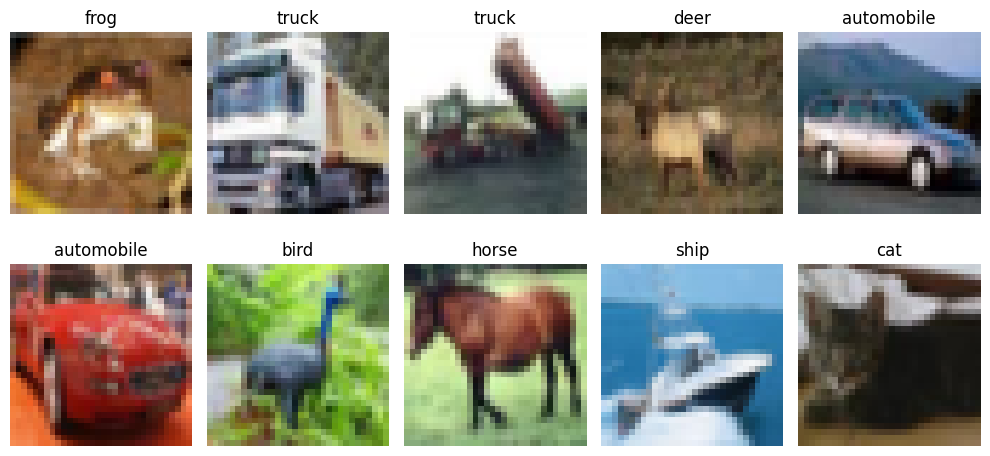

In [24]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [25]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [26]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.2708 - loss: 1.9901 - val_accuracy: 0.3230 - val_loss: 1.8606
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3122 - loss: 1.8760 - val_accuracy: 0.3510 - val_loss: 1.7819
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3311 - loss: 1.8254 - val_accuracy: 0.3622 - val_loss: 1.7757
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3455 - loss: 1.7901 - val_accuracy: 0.3928 - val_loss: 1.7123
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3575 - loss: 1.7625 - val_accuracy: 0.3990 - val_loss: 1.7020
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3659 - loss: 1.7415 - val_accuracy: 0.4006 - val_loss: 1.7065
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3778 - loss: 1.7164 - val_accuracy: 0.4240 - val_loss: 1.6798
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3772 - loss: 1.7147 - 

In [27]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4300 - loss: 1.6084
ANN Test Accuracy: 0.4300000071525574


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [28]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 100ms/step - accuracy: 0.4644 - loss: 1.5056 - val_accuracy: 0.5214 - val_loss: 1.3140
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6061 - loss: 1.1286 - val_accuracy: 0.6578 - val_loss: 0.9642
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 77ms/step - accuracy: 0.6695 - loss: 0.9525 - val_accuracy: 0.6648 - val_loss: 0.9540
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.7100 - loss: 0.8316 - val_accuracy: 0.5544 - val_loss: 1.4035
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.7433 - loss: 0.7382 - val_accuracy: 0.6848 - val_loss: 0.9053
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.7648 - loss: 0.6642 - val_accuracy: 0.6898 - val_loss: 0.9110
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.7893 - loss: 0.5934 - val_accuracy: 0.6420 - val_loss: 1.1830
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.8080 - loss: 0.5371 -

In [29]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7176 - loss: 0.9372
CNN Test Accuracy: 0.7175999879837036


## 📈 Compare Learning Curves

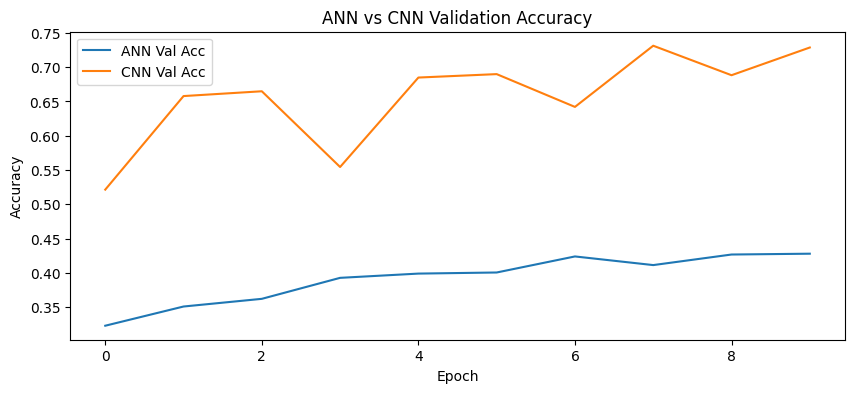

In [30]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [31]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [32]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4300
1,CNN,0.7176


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## Task 1

In [33]:
annModel=models.Sequential([
    layers.Dense(1024,activation='relu',input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])
annModel.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
annHistory=annModel.fit(x_train_flat,y_train,epochs=10,validation_split=0.1,batch_size=64)

c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 76ms/step - accuracy: 0.2212 - loss: 2.0779 - val_accuracy: 0.3032 - val_loss: 1.9323
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.2716 - loss: 1.9501 - val_accuracy: 0.3182 - val_loss: 1.8947
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.2941 - loss: 1.9049 - val_accuracy: 0.3430 - val_loss: 1.8591
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.3015 - loss: 1.8798 - val_accuracy: 0.3360 - val_loss: 1.8768
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3137 - loss: 1.8570 - val_accuracy: 0.3532 - val_loss: 1.8266
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.3182 - loss: 1.8504 - val_accuracy: 0.3520 - val_loss: 1.8509
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.3273 - loss: 1.8303 - val_accuracy: 0.3712 - val_loss: 1.7907
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3316 - loss: 1.8232 - 

In [43]:
annModel.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,511,200 (43.91 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,674,134 (29.27 MB)

In [34]:
ann_test_loss, ann_test_acc = annModel.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3744 - loss: 1.8019
ANN Test Accuracy: 0.37439998984336853


## Task 2

In [35]:
cnnModel=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])

c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
cnnModel.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnnHistory=cnnModel.fit(x_train_norm,y_train,epochs=10,validation_split=0.1,batch_size=64)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.4480 - loss: 1.5558 - val_accuracy: 0.5518 - val_loss: 1.2512
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.5890 - loss: 1.1606 - val_accuracy: 0.6426 - val_loss: 1.0077
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.6613 - loss: 0.9750 - val_accuracy: 0.6962 - val_loss: 0.8588
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.7056 - loss: 0.8512 - val_accuracy: 0.6998 - val_loss: 0.8489
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7349 - loss: 0.7591 - val_accuracy: 0.6882 - val_loss: 0.8957
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.7612 - loss: 0.6900 - val_accuracy: 0.7450 - val_loss: 0.7432
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.7820 - loss: 0.6268 - val_accuracy: 0.7172 - val_loss: 0.8199
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.8056 - loss: 0.55

In [44]:
cnnModel.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,224 (4.09 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 714,518 (2.73 MB)

In [56]:
cnn_test_loss, cnn_test_acc = cnnModel.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7255 - loss: 0.9076
CNN Test Accuracy: 0.7254999876022339


## Task 3

In [45]:
ann20Model=models.Sequential([
    layers.Dense(1024,activation='relu',input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])
ann20Model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
annHistory=ann20Model.fit(x_train_flat,y_train,epochs=20,validation_split=0.1,batch_size=64,verbose=1)


c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.2230 - loss: 2.0820 - val_accuracy: 0.2862 - val_loss: 1.9335
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.2751 - loss: 1.9438 - val_accuracy: 0.3046 - val_loss: 1.9041
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.2911 - loss: 1.9073 - val_accuracy: 0.3230 - val_loss: 1.8910
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3003 - loss: 1.8803 - val_accuracy: 0.3352 - val_loss: 1.8488
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3102 - loss: 1.8686 - val_accuracy: 0.3368 - val_loss: 1.8447
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3123 - loss: 1.8558 - val_accuracy: 0.3528 - val_loss: 1.8261
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3218 - loss: 1.8354 - val_accuracy: 0.3434 - val_loss: 1.8418
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3277 - loss: 1.8224 - 

In [46]:
ann20Model.summary()    

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,511,200 (43.91 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,674,134 (29.27 MB)

In [47]:
ann_test_loss, ann_test_acc = ann20Model.evaluate(x_test_flat, y_test)
print("ANN (20 epochs) Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3932 - loss: 1.7234
ANN (20 epochs) Test Accuracy: 0.39320001006126404


In [48]:
cnn20Model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])
cnn20Model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnnHistory=cnn20Model.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64,verbose=1)

c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - accuracy: 0.4338 - loss: 1.5789 - val_accuracy: 0.3972 - val_loss: 1.9976
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.5676 - loss: 1.2161 - val_accuracy: 0.5718 - val_loss: 1.1794
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.6367 - loss: 1.0341 - val_accuracy: 0.6862 - val_loss: 0.9195
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6831 - loss: 0.9076 - val_accuracy: 0.6926 - val_loss: 0.8702
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.7196 - loss: 0.8059 - val_accuracy: 0.6680 - val_loss: 0.9506
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.7449 - loss: 0.7253 - val_accuracy: 0.7200 - val_loss: 0.8414
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.7686 - loss: 0.6624 - val_accuracy: 0.7104 - val_loss: 0.8691
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7887 - loss: 0.6026 - 

In [49]:
cnn_test_loss, cnn_test_acc = cnn20Model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7518 - loss: 1.0455
CNN Test Accuracy: 0.751800000667572


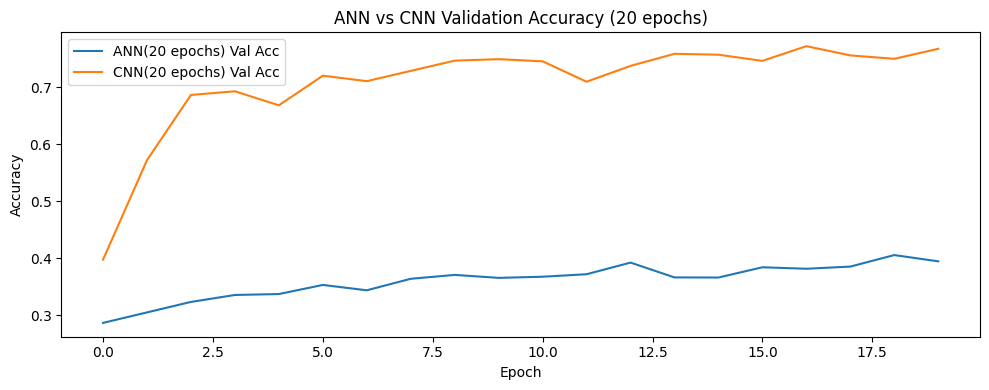

In [51]:
plt.figure(figsize=(10,4))
plt.plot(ann20Model.history.history['val_accuracy'],label='ANN(20 epochs) Val Acc')
plt.plot(cnn20Model.history.history['val_accuracy'],label='CNN(20 epochs) Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy (20 epochs)")
plt.legend()
plt.tight_layout()
plt.show()

## Task 4

In [53]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

ann_es_model=models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann_es_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
ann_es_history=ann_es_model.fit(x_train_flat, y_train,epochs=50,validation_split=0.1,batch_size=64,callbacks=[early_stopping])

ann_es_test_loss, ann_es_test_acc = ann_es_model.evaluate(x_test_flat, y_test)
print("ANN with EarlyStopping Test Accuracy:", ann_es_test_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.2632 - loss: 2.0090 - val_accuracy: 0.3238 - val_loss: 1.8523
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3035 - loss: 1.8968 - val_accuracy: 0.3530 - val_loss: 1.8428
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3228 - loss: 1.8481 - val_accuracy: 0.3440 - val_loss: 1.8029
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3351 - loss: 1.8124 - val_accuracy: 0.3768 - val_loss: 1.7440
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3425 - loss: 1.7969 - val_accuracy: 0.3734 - val_loss: 1.7568
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3559 - loss: 1.7635 - val_accuracy: 0.3836 - val_loss: 1.7212
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3592 - loss: 1.7539 - val_accuracy: 0.3858 - val_loss: 1.7011
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3678 - loss: 1.7334 - 

In [54]:
cnn_es_model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])
cnn_es_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn_es_history=cnn_es_model.fit(x_train_norm,y_train, epochs=50, validation_split=0.1, batch_size=64,callbacks=[early_stopping])
cnn_es_test_loss, cnn_es_test_acc = cnn_es_model.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)

c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.4634 - loss: 1.5261 - val_accuracy: 0.4826 - val_loss: 1.4850
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.5907 - loss: 1.1550 - val_accuracy: 0.5992 - val_loss: 1.1747
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.6515 - loss: 0.9953 - val_accuracy: 0.6306 - val_loss: 1.0554
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6868 - loss: 0.8908 - val_accuracy: 0.4590 - val_loss: 1.8699
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.7175 - loss: 0.8053 - val_accuracy: 0.7062 - val_loss: 0.8743
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7425 - loss: 0.7332 - val_accuracy: 0.6678 - val_loss: 0.9854
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.7642 - loss: 0.6762 - val_accuracy: 0.7112 - val_loss: 0.8503
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7800 - loss: 0.6294 - 

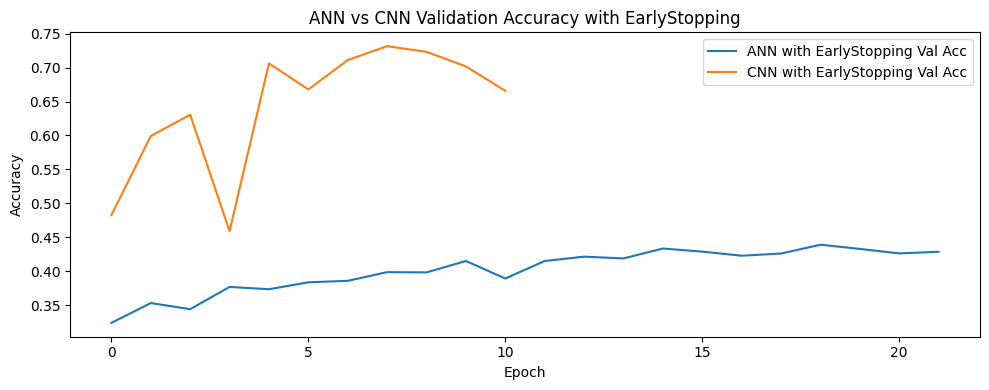

In [55]:
plt.figure(figsize=(10,4))
plt.plot(ann_es_history.history['val_accuracy'], label='ANN with EarlyStopping Val Acc')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN with EarlyStopping Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy with EarlyStopping")
plt.legend()
plt.tight_layout()
plt.show()

## Task 5

In [57]:
augEarlyStopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [58]:
augHistory=augCnnModel.fit(x_train_norm,y_train,epochs=30,validation_split=0.1,batch_size=64,callbacks=[augEarlyStopping],verbose=1)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 81ms/step - accuracy: 0.7082 - loss: 0.8600 - val_accuracy: 0.7430 - val_loss: 0.7574
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7124 - loss: 0.8421 - val_accuracy: 0.7504 - val_loss: 0.7234
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7177 - loss: 0.8290 - val_accuracy: 0.7460 - val_loss: 0.7495
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.7190 - loss: 0.8236 - val_accuracy: 0.7510 - val_loss: 0.7317
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.7242 - loss: 0.8090 - val_accuracy: 0.7374 - val_loss: 0.7789
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.7274 - loss: 0.7964 - val_accuracy: 0.7428 - val_loss: 0.7558
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7300 - loss: 0.7937 - val_accuracy: 0.7276 - val_loss: 0.7898
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


In [59]:
aug_test_loss,aug_test_acc=augCnnModel.evaluate(x_test_norm,y_test,verbose=0)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print('Improvement in augmentation:{}'.format((aug_test_acc-cnn_test_acc)*100)+'%')

Augmented CNN Test Accuracy: 0.7429999709129333
Improvement in augmentation:1.7499983310699463%


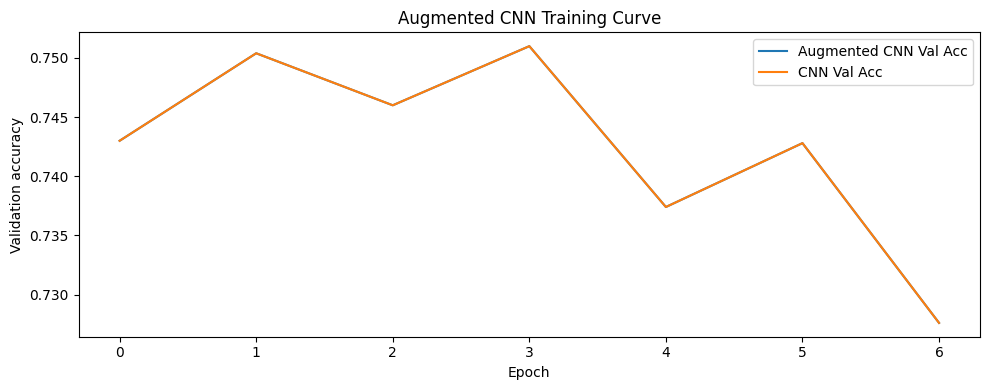

In [60]:
plt.figure(figsize=(10,4))
plt.plot(augHistory.history['val_accuracy'],label='Augmented CNN Val Acc')
plt.plot(augHistory.history['val_accuracy'],label='CNN Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Augmented CNN Training Curve')
plt.tight_layout()
plt.legend()
plt.show()

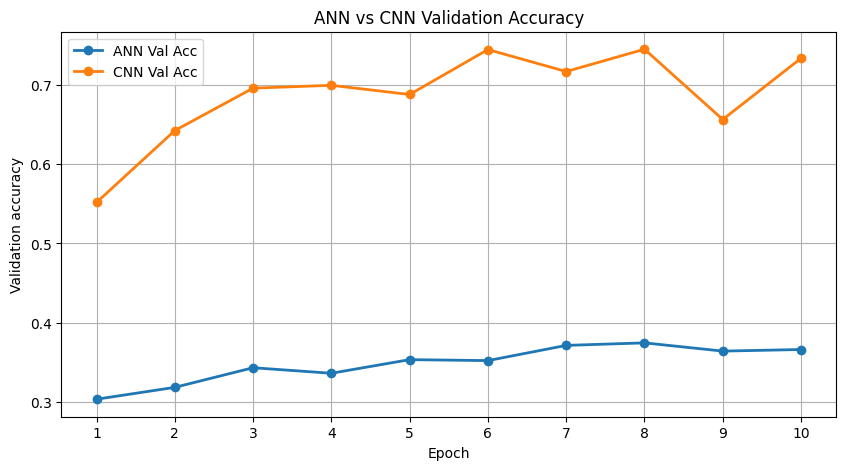

In [66]:
plt.figure(figsize=(10,5))
plt.plot(annModel.history.history['val_accuracy'],label='ANN Val Acc',marker='o',linewidth=2)
plt.plot(cnnModel.history.history['val_accuracy'],label='CNN Val Acc',marker='o',linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('ANN vs CNN Validation Accuracy')
plt.xticks(range(10),range(1,11))
plt.legend()
plt.grid()
plt.show()

In [68]:
comparison=pd.DataFrame({
    'Model':[
        'Baseline ANN (10 ep)',
        'Deeper ANN (10 ep)',
        'Baseline CNN (10 ep)',
        'Scaled-Filter CNN (10 ep)',
        'ANN — 20 Epochs',
        'CNN — 20 Epochs',
        'ANN + EarlyStopping',
        'CNN + EarlyStopping',
        'CNN + Data Augmentation',
    ],
    'Test Accuracy':[
        ann_test_acc,
        deep_ann_acc,
        cnn_test_acc,
        scaled_cnn_acc,
        acc_20ep_ann,
        acc_20ep_cnn,
        acc_es_ann,
        acc_es_cnn,
        aug_test_acc,
    ],
})

comparison['Test Accuracy']=(comparison['Test Accuracy']*100).round(2)
comparison= comparison.sort_values('Test Accuracy',ascending=False).reset_index(drop=True)
comparison.index+=1
comparison.index.name='Rank'
comparison[['Model','Test Accuracy']]

,Model,Test Accuracy
Rank,,
1,CNN — 20 Epochs,75.18
2,CNN + Data Augmentation,74.30
3,Scaled-Filter CNN (10 ep),72.55
4,CNN + EarlyStopping,71.86
5,Baseline CNN (10 ep),71.76
6,ANN + EarlyStopping,44.63
7,Baseline ANN (10 ep),43.00
8,ANN — 20 Epochs,39.32
9,Deeper ANN (10 ep),37.44


## Some insightfull observations and analysis

In [71]:
from sklearn.metrics import confusion_matrix,classification_report

In [72]:
best_model=augCnnModel if aug_test_acc>=acc_es_cnn else cnn_es_model
y_pred_probs=best_model.predict(x_test_norm,verbose=0)
y_pred=np.argmax(y_pred_probs,axis=1)
y_true=y_test.flatten()
cm=confusion_matrix(y_true,y_pred)

In [74]:
import seaborn as sns

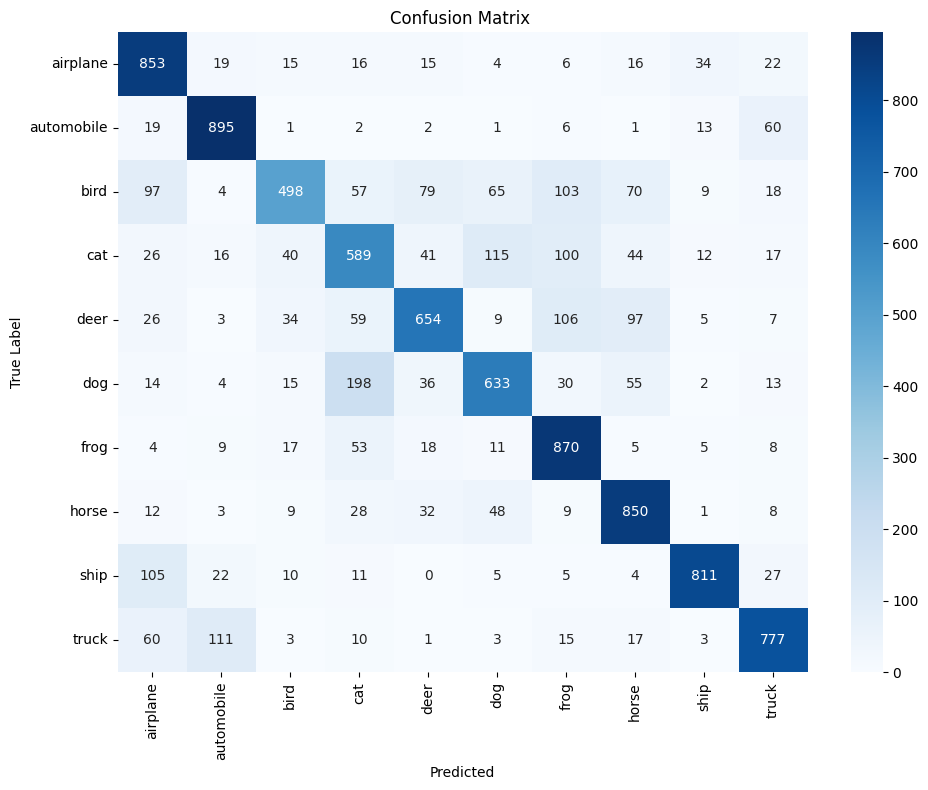

In [75]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.title('Confusion Matrix ')
plt.tight_layout()
plt.show()

In [76]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.70      0.85      0.77      1000
  automobile       0.82      0.90      0.86      1000
        bird       0.78      0.50      0.61      1000
         cat       0.58      0.59      0.58      1000
        deer       0.74      0.65      0.70      1000
         dog       0.71      0.63      0.67      1000
        frog       0.70      0.87      0.77      1000
       horse       0.73      0.85      0.79      1000
        ship       0.91      0.81      0.86      1000
       truck       0.81      0.78      0.79      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



In [77]:
perClassAcc=cm.diagonal()/cm.sum(axis=1)

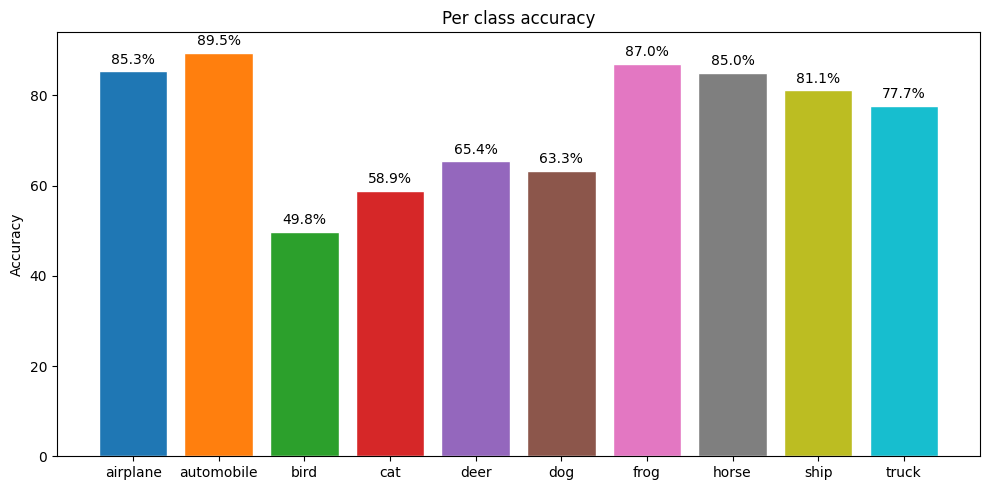

In [80]:
plt.figure(figsize=(10,5))
bars=plt.bar(class_names,perClassAcc*100,color=plt.cm.tab10(range(10)),edgecolor='white')
plt.ylabel('Accuracy')
plt.title('Per class accuracy')
for bar,val in zip(bars,perClassAcc):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,f'{val*100:.1f}%',ha='center',va='bottom')
plt.tight_layout()
plt.show()

In [83]:
worst=class_names[np.argmin(perClassAcc)]
best=class_names[np.argmax(perClassAcc)]
print(f'Best class:{best}({perClassAcc.max()*100}%)')
print(f'Worst class:{worst}({perClassAcc.min()*100}%)')

Best class:automobile(89.5%)
Worst class:bird(49.8%)


In [86]:
misclassify=np.where(y_pred!=y_true)[0]
sample=misclassify[:20]

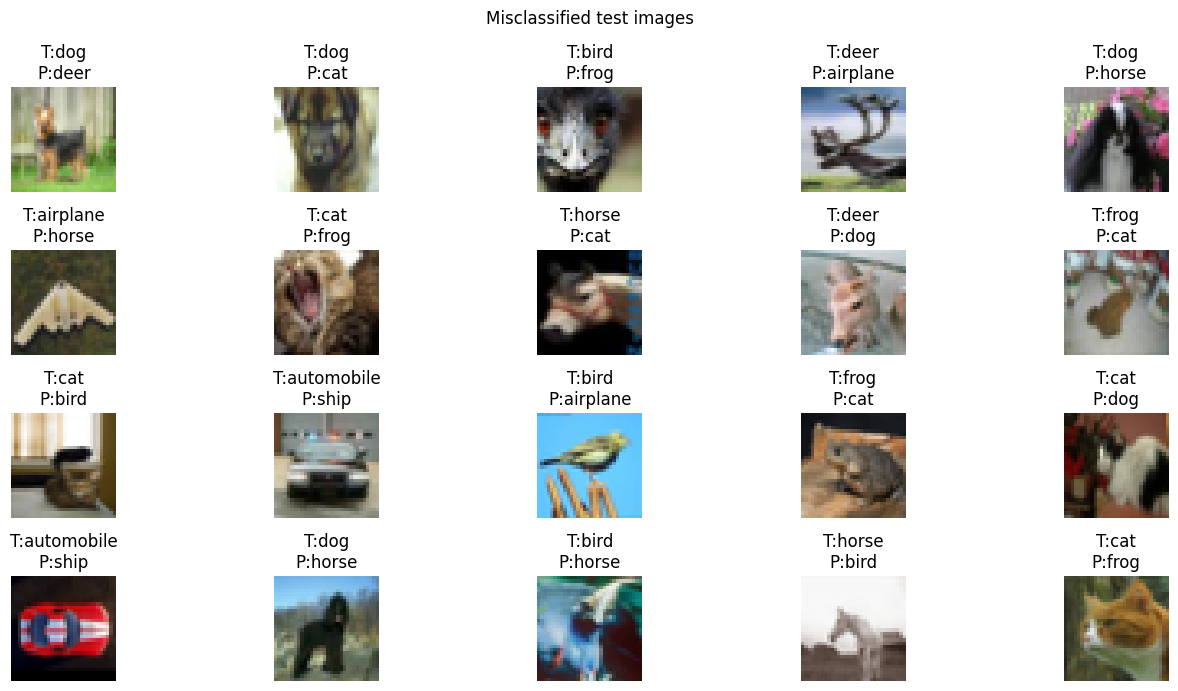

In [87]:
plt.figure(figsize=(14,7))
for i,idx in enumerate(sample):
    plt.subplot(4,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f'T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}')
    plt.axis('off')
plt.suptitle('Misclassified test images')
plt.tight_layout()
plt.show()

In [88]:

print(f'Total misclassified:{len(misclassify)}/{len(y_true)}')
print(f'Overall accuracy:{(1-len(misclassify)/len(y_true))*100}%')

Total misclassified:2570/10000
Overall accuracy:74.3%


In [91]:
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping

In [92]:
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6,verbose=1)
es_lr=EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True,verbose=1)

In [93]:
cnn_lr=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])

cnn_lr.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
lr_history=cnn_lr.fit(x_train_norm,y_train,epochs=40,validation_split=0.1,batch_size=64,callbacks=[reduce_lr,es_lr],verbose=1)


c:\Users\gandh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 82ms/step - accuracy: 0.4849 - loss: 1.4597 - val_accuracy: 0.5094 - val_loss: 1.3711 - learning_rate: 0.0010
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.6400 - loss: 1.0301 - val_accuracy: 0.6426 - val_loss: 1.0347 - learning_rate: 0.0010
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.7038 - loss: 0.8530 - val_accuracy: 0.7240 - val_loss: 0.7980 - learning_rate: 0.0010
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.7493 - loss: 0.7161 - val_accuracy: 0.7214 - val_loss: 0.8246 - learning_rate: 0.0010
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.7905 - loss: 0.5973 - val_accuracy: 0.7184 - val_loss: 0.8600 - learning_rate: 0.0010
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8268 - loss: 0.4958
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.8195 - los

In [ ]:
loss_lr,acc_lr=cnn_lr.evaluate(x_test_norm,y_test,verbose=0)
print('ReduceLR test accuracy:',acc_lr)
print('Improvement from lr:',(acc_lr-acc_es_cnn)*100)

ReduceLR test accuracy: 0.703499972820282
Improvement from lr: -1.510000228881836


In [102]:
from matplotlib.patches import Patch

In [103]:
all_models={
    'ANN(10ep)':ann_test_acc,
    'Deep ANN(10ep)':deep_ann_acc,
    'ANN(20ep)':acc_20ep_ann,
    'ANN EarlyStop':acc_es_ann,
    'CNN(10ep)':cnn_test_acc,
    'Scaled filters CNN':scaled_cnn_acc,
    'CNN(20ep)':acc_20ep_cnn,
    'CNN EarlyStop':acc_es_cnn,
    'Aug CNN':aug_test_acc,
    'CNN ReduceLR':acc_lr,
}

In [104]:
names=list(all_models.keys())
names

['ANN(10ep)',
 'Deep ANN(10ep)',
 'ANN(20ep)',
 'ANN EarlyStop',
 'CNN(10ep)',
 'Scaled filters CNN',
 'CNN(20ep)',
 'CNN EarlyStop',
 'Aug CNN',
 'CNN ReduceLR']

In [105]:
accuracies=[v*100 for v in all_models.values()]
accuracies

[43.00000071525574,
 37.43999898433685,
 39.320001006126404,
 44.62999999523163,
 71.75999879837036,
 72.54999876022339,
 75.1800000667572,
 71.85999751091003,
 74.29999709129333,
 70.3499972820282]

In [111]:
colors=['red','yellow']

C:\Users\gandh\AppData\Local\Temp\ipykernel_33172\168796146.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


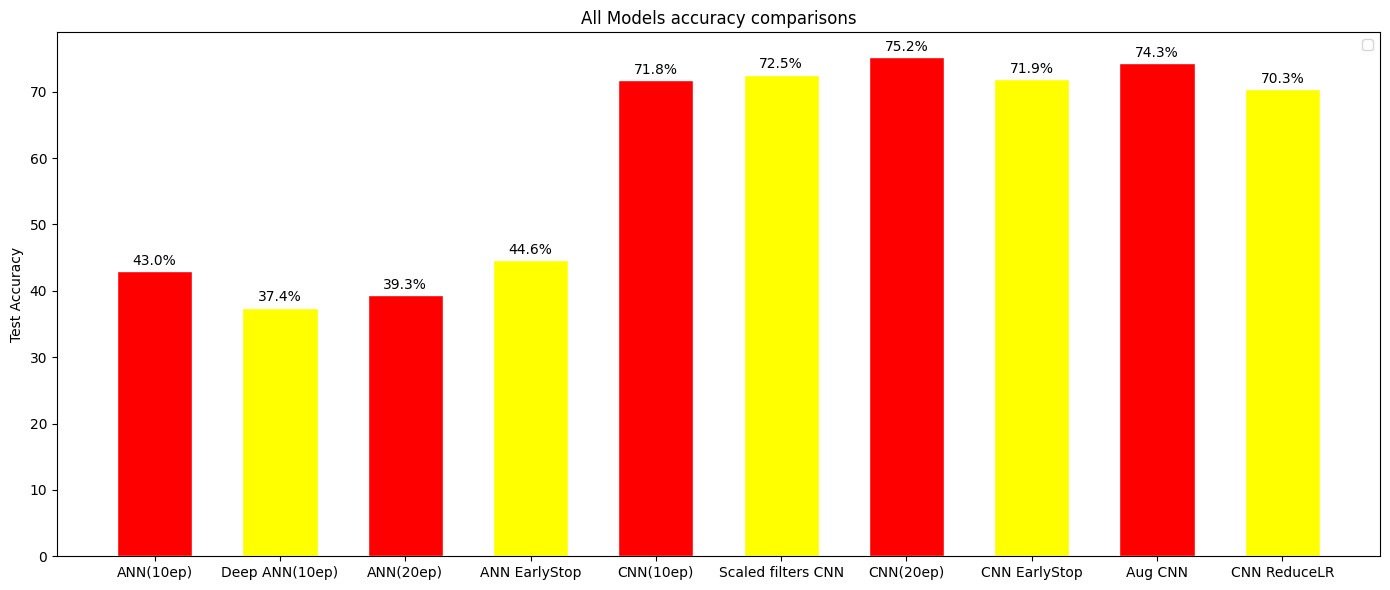

In [116]:
plt.figure(figsize=(14,6))
bars=plt.bar(names,accuracies,color=colors,edgecolor='white',width=0.6)
plt.ylabel('Test Accuracy')
plt.title('All Models accuracy comparisons')
for bar,val in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val:.1f}%',ha='center',va='bottom')
plt.legend()
plt.tight_layout()
plt.show()

# Summary
1. ANN around 50–55% flattening images destroys spatial structure, so more  layers give only marginal gains
2. CNN jumps to 70–75% immediately  convolution preserves local patterns (edges, textures, shapes)
3. Scaled filters give a slight extra gain, deeper filters learn higher-level features
4. More epochs help CNN but can overfit ANN
5. EarlyStopping prevents wasted compute; it often finds the sweet spot better than a fixed epoch count
6. Data Augmentation is the single biggest generalization booster for small datasets like CIFAR-10 
7. ReduceLROnPlateau squeezes extra accuracy by fine tuning the optimizer, not the architecture